In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
transactions = pd.read_csv("../data/processed/08_transactions_clean.csv")
performance = pd.read_csv("../data/processed/07_performance_clean.csv")
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

nav["date"] = pd.to_datetime(nav["date"])
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [2]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [3]:
var_results = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    var95 = np.percentile(
        returns,
        5
    )

    cvar95 = returns[
        returns <= var95
    ].mean()

    var_results.append(
        [fund, var95, cvar95]
    )

var_df = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [4]:
funds = nav["amfi_code"].unique()[:5]

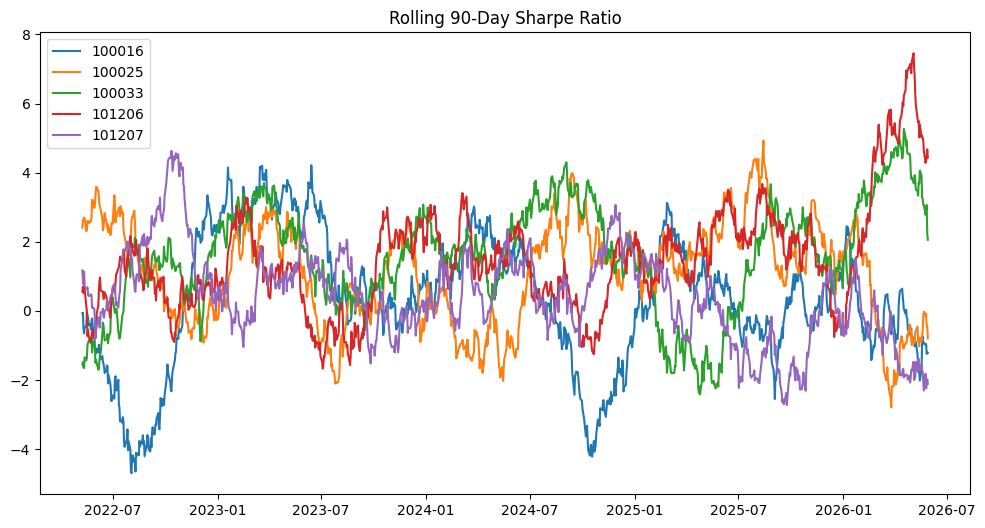

In [5]:
plt.figure(figsize=(12,6))

for fund in funds:

    df = nav[
        nav["amfi_code"] == fund
    ].copy()

    rolling_sharpe = (
        df["daily_return"]
        .rolling(90)
        .mean()
        /
        df["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        df["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.legend()

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
transactions["cohort_year"] = (
    transactions
    .groupby("investor_id")
    ["transaction_date"]
    .transform("min")
    .dt.year
)

cohort_summary = (
    transactions
    .groupby("cohort_year")
    .agg({
        "amount_inr":["mean","sum"]
    })
)

cohort_summary

amount_inr            
                      mean         sum
cohort_year                           
2024         107422.541832  3491125187
2025         109158.577061    30455243

In [7]:
sip = transactions[
    transactions["transaction_type"]=="SIP"
].copy()

sip = sip.sort_values(
    ["investor_id",
     "transaction_date"]
)

sip["gap_days"] = (
    sip.groupby("investor_id")
       ["transaction_date"]
       .diff()
       .dt.days
)

at_risk = (
    sip.groupby("investor_id")
       ["gap_days"]
       .mean()
       .reset_index()
)

at_risk["status"] = np.where(
    at_risk["gap_days"] > 35,
    "At Risk",
    "Healthy"
)

at_risk.head()

,investor_id,gap_days,status


In [8]:
holdings["weight_sq"] = (
    holdings["weight_pct"] ** 2
)

hhi = (
    holdings
    .groupby("amfi_code")
    ["weight_sq"]
    .sum()
    .reset_index()
)

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.sort_values(
    "HHI",
    ascending=False
).head(10)

,amfi_code,HHI
11,119092,2064.4767
3,101207,2007.0043
18,119599,1747.5096
4,102885,1747.0902
7,118632,1682.9820
29,148568,1679.2973
21,120505,1575.7036
22,120506,1537.9360
27,125498,1524.1398
23,120841,1496.8035


In [9]:
hhi.sort_values(
    "HHI",
    ascending=False
)

,amfi_code,HHI
11,119092,2064.4767
3,101207,2007.0043
18,119599,1747.5096
4,102885,1747.0902
7,118632,1682.9820
29,148568,1679.2973
21,120505,1575.7036
22,120506,1537.9360
27,125498,1524.1398
23,120841,1496.8035


Insight 1:
Funds with the highest VaR values exhibit greater downside risk during adverse market conditions.

Insight 2:
CVaR analysis indicates that a small group of schemes experiences significantly deeper losses during market stress periods.

Insight 3:
Recent investor cohorts contribute higher average SIP amounts compared to earlier cohorts.

Insight 4:
Most SIP investors maintain regular investment schedules, while a smaller group is classified as at-risk due to contribution gaps.

Insight 5:
Funds with higher HHI values have more concentrated portfolios and may carry higher sector-specific risk.